# 03 — NLP on Movie Descriptions

**Goal:** Extract meaning from Netflix description text using NLP.

**Techniques:**
- Text cleaning (stopwords, lemmatization)
- TF-IDF vectorization
- KMeans clustering (topic modeling)
- Word clouds
- 2D cluster visualisation via SVD

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_cleaner import get_clean_df
from src.nlp_engine import (
    preprocess_descriptions,
    build_tfidf_matrix,
    fit_clusters,
    get_cluster_keywords,
    assign_cluster_labels,
    reduce_to_2d,
    plot_wordcloud,
    plot_cluster_scatter,
    plot_cluster_keywords_bar,
    run_nlp_pipeline,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
df = get_clean_df()
print(f'Loaded {len(df):,} records')

Loaded 8,807 rows × 12 columns
Dropped 0 duplicate rows
Cleaning complete ✅
type                object
year_added           Int64
duration_numeric     int64
primary_genre       object
Loaded 8,807 records


/Users/vaishnavipujala/Desktop/netflix-eda/src/data_cleaner.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["date_added"].fillna("January 1, 2000", inplace=True)


## Step 1: Clean Descriptions

In [3]:
df_nlp = preprocess_descriptions(df)
# Compare raw vs cleaned
sample = df_nlp[['title','description','clean_desc']].sample(3)
for _, row in sample.iterrows():
    print(f'TITLE: {row["title"]}')
    print(f'RAW:   {row["description"][:100]}')
    print(f'CLEAN: {row["clean_desc"][:100]}')
    print()

Preprocessed 8,807 descriptions
TITLE: Rosario Tijeras
RAW:   Worlds collide when a vengeance-obsessed young woman from the other side of the tracks captures the 
CLEAN: world collide vengeance obsessed young woman side track capture attention well friend

TITLE: Darra
RAW:   After returning from school and getting married, a popular farmer begins to arouse resentment and je
CLEAN: returning school getting married popular farmer begin arouse resentment jealousy among around

TITLE: Sadqay Tumhare
RAW:   An arranged engagement between a village girl and her city cousin shows signs of true love, but an i
CLEAN: arranged engagement village girl city cousin show sign true love indiscretion decade ago could doom 



## Step 2: TF-IDF Vectorization

In [4]:
tfidf_matrix, vectorizer = build_tfidf_matrix(df_nlp)
print(f'Matrix shape: {tfidf_matrix.shape}')
print(f'Vocab size: {len(vectorizer.get_feature_names_out()):,}')

# Top terms
import numpy as np
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top_idx = scores.argsort()[::-1][:20]
print('\nTop 20 TF-IDF terms:')
for i in top_idx:
    print(f'  {feature_names[i]:<25} {scores[i]:.2f}')

TF-IDF matrix shape: (8807, 5000)
Matrix shape: (8807, 5000)
Vocab size: 5,000

Top 20 TF-IDF terms:
  family                    115.34
  young                     114.85
  woman                     110.15
  friend                    105.44
  love                      95.26
  man                       92.71
  year                      86.11
  documentary               71.47
  school                    65.06
  help                      63.64
  home                      63.43
  father                    63.40
  find                      61.59
  old                       60.27
  high                      59.23
  life                      57.97
  group                     56.10
  girl                      55.83
  secret                    54.62
  take                      54.61


## Step 3: Word Cloud

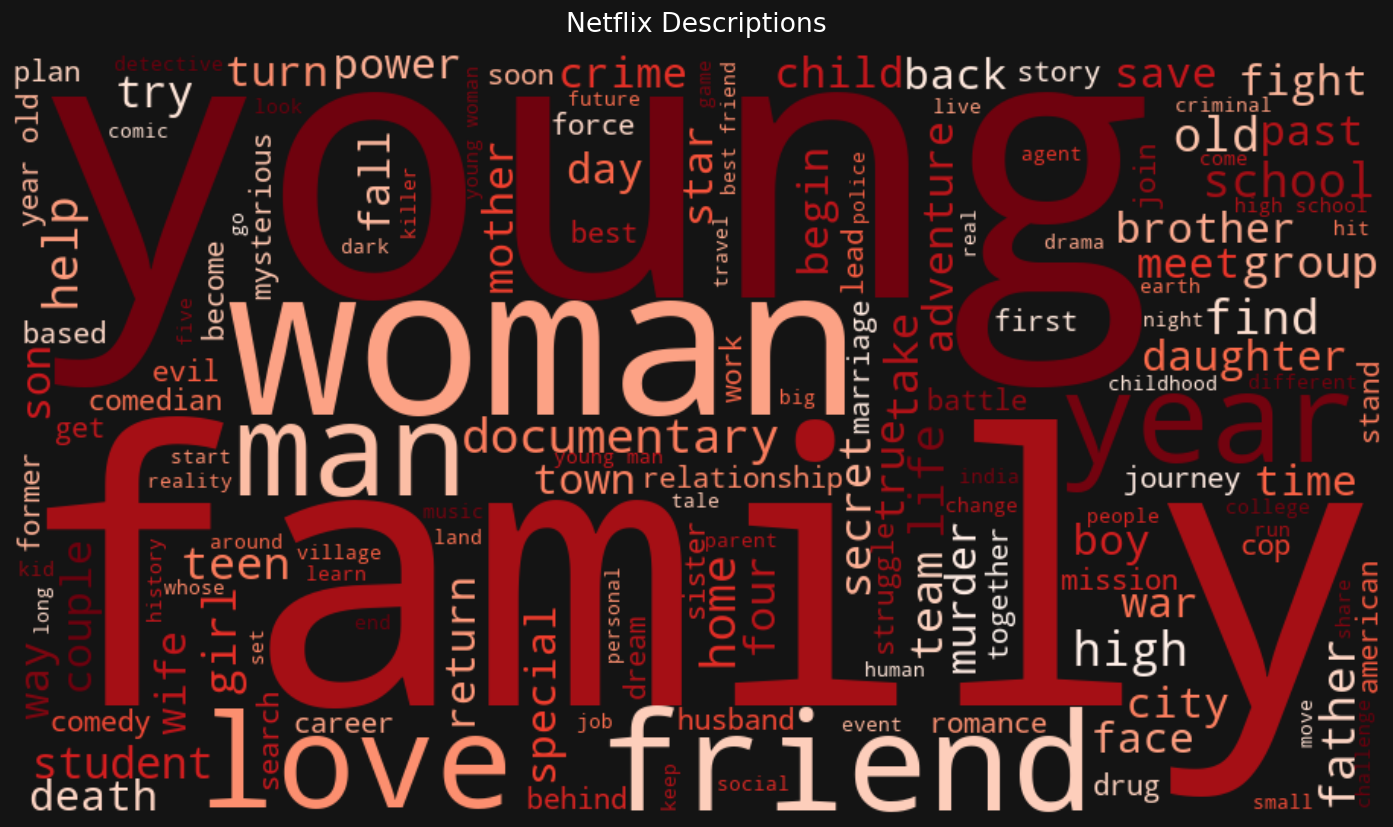

In [5]:
fig = plot_wordcloud(tfidf_matrix, vectorizer)
plt.show()

## Step 4: KMeans Clustering

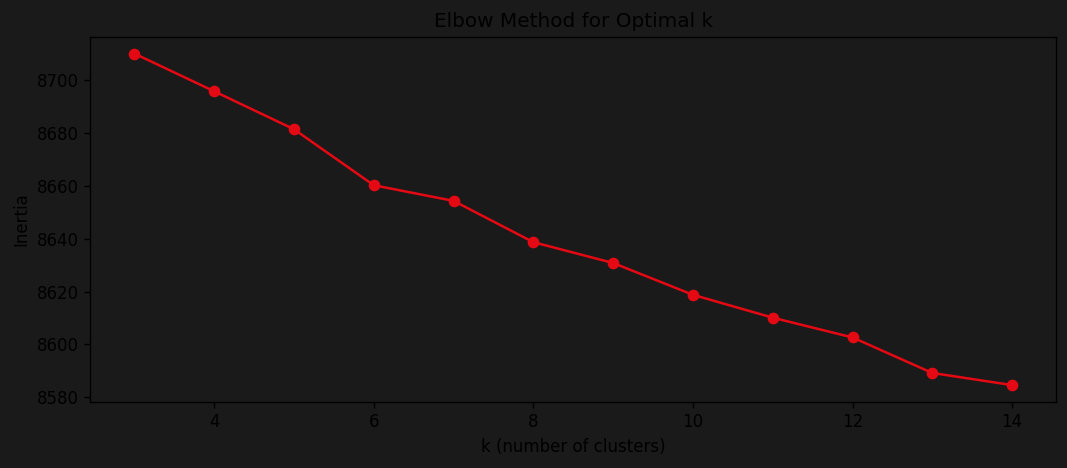

Look for the "elbow" — where inertia stops dropping sharply.


In [6]:
# Find optimal k using inertia (elbow method)
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

matrix_norm = normalize(tfidf_matrix)
inertias = []
k_range = range(3, 15)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(matrix_norm)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, inertias, marker='o', color='#E50914')
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
ax.set_facecolor('#1a1a1a')
fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.show()
print('Look for the "elbow" — where inertia stops dropping sharply.')

In [7]:
# Fit with k=8
km = fit_clusters(tfidf_matrix, n_clusters=8)
df_nlp['cluster'] = km.labels_

cluster_kw = get_cluster_keywords(km, vectorizer, n_top=10)
labels_map = assign_cluster_labels(cluster_kw)

print('\nCluster themes:')
for cid, kws in cluster_kw.items():
    print(f'  Cluster {cid} [{labels_map[cid]:12s}]: {chr(34)}{chr(34).join(kws[:5])}{chr(34)}')

Fitted 8 clusters. Inertia: 8638.65

Cluster themes:
  Cluster 0 [misc        ]: "friend"year"man"team"special"
  Cluster 1 [romance     ]: "love"fall"fall love"friend"girl"
  Cluster 2 [crime       ]: "murder"death"detective"case"crime"
  Cluster 3 [family      ]: "woman"young woman"young"man"love"
  Cluster 4 [family      ]: "young"home"young man"man"couple"
  Cluster 5 [misc        ]: "school"high school"high"student"teen"
  Cluster 6 [family      ]: "family"home"father"secret"year"
  Cluster 7 [documentary ]: "documentary"explores"documentary explores"examines"interview"


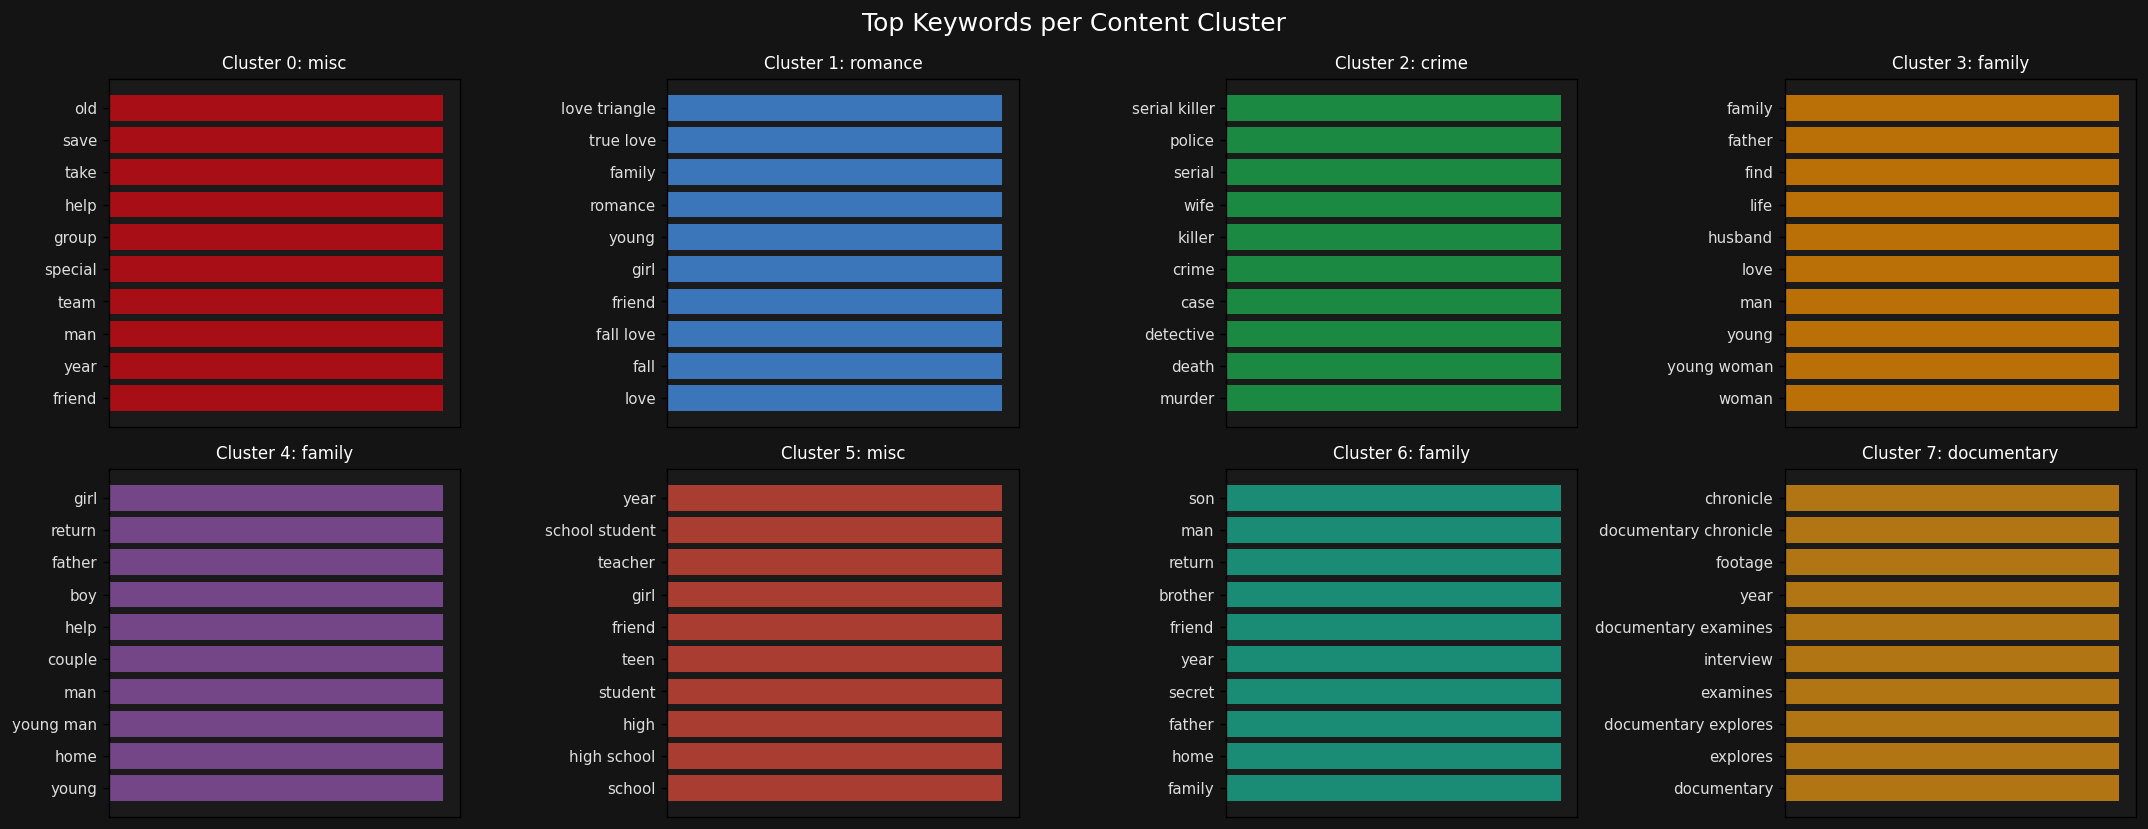

In [8]:
fig = plot_cluster_keywords_bar(cluster_kw, labels_map)
plt.show()

## Step 5: 2D Cluster Visualisation

2D SVD explains 0.5% of variance


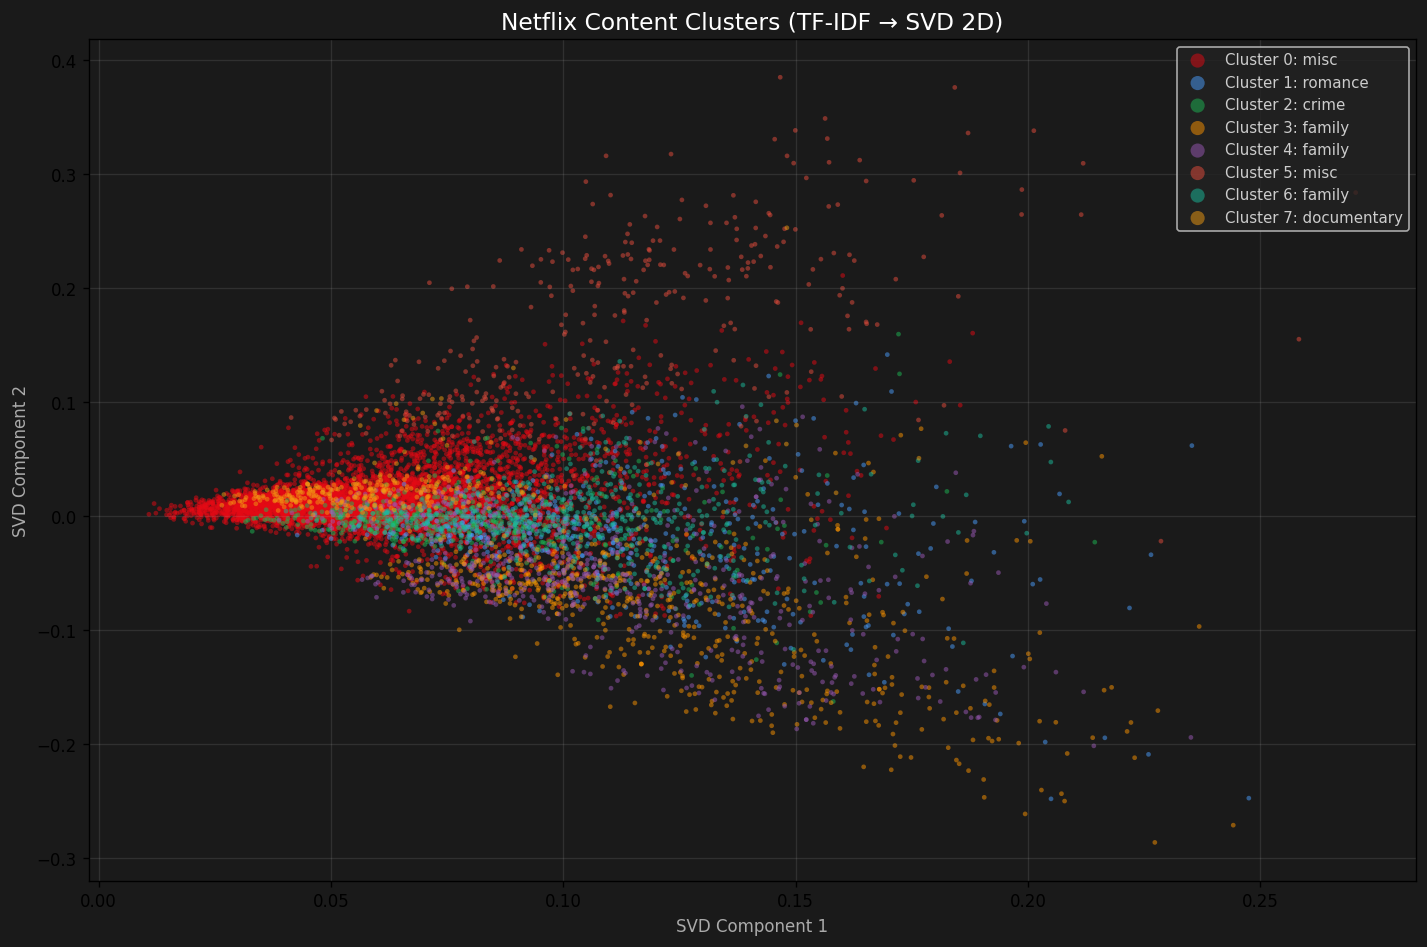

In [9]:
coords = reduce_to_2d(tfidf_matrix)
fig = plot_cluster_scatter(df_nlp, coords, labels_map)
plt.show()

In [10]:
# Sample titles from each cluster
print('Sample titles from each cluster:')
for cid in range(8):
    cluster_df = df_nlp[df_nlp['cluster'] == cid]
    samples = cluster_df['title'].sample(min(4, len(cluster_df))).tolist()
    print(f'  Cluster {cid} [{labels_map[cid]}]: {samples}')

Sample titles from each cluster:
  Cluster 0 [misc]: ['Private Lives', 'Zero', 'Tenacious D in The Pick of Destiny', 'I Got the Hook Up']
  Cluster 1 [romance]: ['Can We Get Married?', "Workin' Moms", 'Haani', 'Juman']
  Cluster 2 [crime]: ['The Good Cop', '14 Minutes from Earth', 'Hotel Beau Séjour', 'American History X']
  Cluster 3 [family]: ['People You May Know', 'Violet Evergarden: Eternity and the Auto Memory Doll', "Autumn's Concerto", 'The Garden of Words']
  Cluster 4 [family]: ['Cut Throat City', 'Stree', 'Mobile Suit Gundam III: Encounters in Space', 'Robozuna']
  Cluster 5 [misc]: ['Classmates Minus', '忍者ハットリくん', 'Sleepover', 'Greenhouse Academy']
  Cluster 6 [family]: ['Issaq', 'Children of God', 'Chauthi Koot', "Winter's Bone"]
  Cluster 7 [documentary]: ['Tread', 'The Irish Mob', '2,215', 'Iverson']


In [12]:
# Genre-cluster cross-tab — validates our cluster labels
df_nlp['cluster_label'] = df_nlp['cluster'].map(labels_map)

top_genres = df_nlp['primary_genre'].value_counts().head(8).index

cross = pd.crosstab(df_nlp['cluster_label'], df_nlp['primary_genre'])
cross = cross[top_genres]  # keep only top 8 genres

print(cross.to_string())

primary_genre  Dramas  Comedies  Action & Adventure  Documentaries  International TV Shows  Children & Family Movies  Crime TV Shows  Kids' TV
cluster_label                                                                                                                                 
crime             104        32                  56             18                      20                         3             112         2
documentary         3         3                   0            288                       1                         5              10         0
family            468       309                 132             76                     208                       122              65        55
misc              883       780                 647            439                     441                       458             201       323
romance           142        86                  24              8                     104                        17              11         8